# Art Expert - Artist Identification CNN Training

This notebook implements a Convolutional Neural Network for identifying the artist of artwork images using TensorFlow and Keras.

# Imports

In [ ]:
#!pip install Keras-Preprocessing

In [1]:
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix

from datasets import load_dataset
from collections import Counter

from PIL import Image

from google.colab import userdata

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
Keras version: 3.13.2
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Early stopping

In [2]:
tf.random.set_seed(42)
class CustomEarlyStopping(tf.keras.callbacks.EarlyStopping):
    def on_epoch_end(self, epoch, logs=None):
        super().on_epoch_end(epoch, logs)
        if self.model.stop_training:
            print(f"\nTraining early stopped on epoch {epoch+1} (no improvement in val_loss).")

early_stop = CustomEarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train and evaluate

In [3]:
def train_and_evaluate(
    model,
    train_data,
    val_data,
    test_data,
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"],
    epochs = 10,
    callbacks = None,
    verbose_level = 2,
):
    callbacks = callbacks or []

    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=epochs,
        callbacks=callbacks,
        verbose=verbose_level,
    )

    test_results = model.evaluate(
        test_data,
        verbose=verbose_level,
        return_dict=True
    )

    test_loss = test_results["loss"]

    acc_key = next((k for k in test_results if "acc" in k.lower()), None)
    test_acc = test_results[acc_key] if acc_key is not None else None

    # Crear figura y ocultar ejes
    fig, ax = plt.subplots(figsize=(4, 1.5))
    ax.axis('off')

    # Añadir el texto centrado
    ax.text(
        0.5, 0.5,
        f'Precisión en test: {test_acc:.4f}',
        ha='center', va='center',
        fontsize=16
    )

    plt.show()

    fig, ax1 = plt.subplots()

    # Número de épocas
    epochs = range(1, len(history.history['accuracy']) + 1)

    # Accuracy en el eje izquierdo
    ax1.plot(epochs, history.history['accuracy'],       label='Accuracy entrenamiento')
    ax1.plot(epochs, history.history['val_accuracy'],   label='Accuracy validación')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Accuracy')
    ax1.legend(loc='upper left')

    # Loss en un eje derecho (twinx)
    ax2 = ax1.twinx()
    ax2.plot(epochs, history.history['loss'],           linestyle='--', label='Loss entrenamiento')
    ax2.plot(epochs, history.history['val_loss'],       linestyle=':',  label='Loss validación')
    ax2.set_ylabel('Loss')
    ax2.legend(loc='upper right')

    plt.title('Accuracy y Loss durante el entrenamiento')
    plt.grid(True)
    plt.show()

    # Confusion matrix
    y_pred_probs = model.predict(test_data, verbose=verbose_level)
    y_pred = np.argmax(y_pred_probs, axis=1)

    y_true_batches = []
    for batch in test_data:
        x_batch, y_batch = batch
        y_batch = np.array(y_batch)

        if y_batch.ndim > 1 and y_batch.shape[-1] == 1:
            y_batch = y_batch.squeeze(-1)

        if y_batch.ndim > 1:
            y_batch = np.argmax(y_batch, axis=1)

        y_true_batches.append(y_batch)

    y_true = np.concatenate(y_true_batches)

    n = min(len(y_true), len(y_pred))
    y_true = y_true[:n]
    y_pred = y_pred[:n]

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest')
    plt.title('Matriz de confusión')
    plt.xlabel('Etiqueta Predicha')
    plt.ylabel('Etiqueta Verdadera')
    plt.colorbar()
    plt.grid(False)
    plt.show()

    return history, test_results

# Dataset

In [18]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

def transform_batch(batch):
    images = []
    labels = batch["artist"]

    for img in batch["image"]:
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.array(img))
        img = img.convert("RGB")
        img = img.resize((IMG_WIDTH, IMG_HEIGHT))
        images.append(np.array(img, dtype=np.uint8))

    return {
        "pixel_values": images,
        "label": labels,
    }

In [5]:
# Load the WikiArt dataset
# https://huggingface.co/datasets/huggan/wikiart
print("Loading WikiArt dataset from Hugging Face...")
# Load only first X rows
dataset = load_dataset("huggan/wikiart", split="train[:1000]")

print(len(dataset))

print(dataset.features["artist"])
print(dataset.features["genre"])
print(dataset.features["style"])

artist_names = dataset.features["artist"].names
genre_names = dataset.features["genre"].names
style_names = dataset.features["style"].names

split_1 = dataset.train_test_split(test_size=0.2, seed=42)
train_hf = split_1["train"]
temp_hf = split_1["test"]

split_2 = temp_hf.train_test_split(test_size=0.5, seed=42)
val_hf = split_2["train"]
test_hf = split_2["test"]

train_hf = train_hf.with_transform(transform_batch)
val_hf = val_hf.with_transform(transform_batch)
test_hf = test_hf.with_transform(transform_batch)

train_ds = train_hf.to_tf_dataset(
    columns="pixel_values",
    label_cols="label",
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_ds = val_hf.to_tf_dataset(
    columns="pixel_values",
    label_cols="label",
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = test_hf.to_tf_dataset(
    columns="pixel_values",
    label_cols="label",
    batch_size=BATCH_SIZE,
    shuffle=False,
)

Loading WikiArt dataset from Hugging Face...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00072.parquet:   0%|          | 0.00/522M [00:00<?, ?B/s]

...

data/train-00069-of-00072.parquet:   0%|          | 0.00/454M [00:00<?, ?B/s]

data/train-00070-of-00072.parquet:   0%|          | 0.00/486M [00:00<?, ?B/s]

data/train-00071-of-00072.parquet:   0%|          | 0.00/367M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/81444 [00:00<?, ? examples/s]

1000
ClassLabel(names=['Unknown Artist', 'boris-kustodiev', 'camille-pissarro', 'childe-hassam', 'claude-monet', 'edgar-degas', 'eugene-boudin', 'gustave-dore', 'ilya-repin', 'ivan-aivazovsky', 'ivan-shishkin', 'john-singer-sargent', 'marc-chagall', 'martiros-saryan', 'nicholas-roerich', 'pablo-picasso', 'paul-cezanne', 'pierre-auguste-renoir', 'pyotr-konchalovsky', 'raphael-kirchner', 'rembrandt', 'salvador-dali', 'vincent-van-gogh', 'hieronymus-bosch', 'leonardo-da-vinci', 'albrecht-durer', 'edouard-cortes', 'sam-francis', 'juan-gris', 'lucas-cranach-the-elder', 'paul-gauguin', 'konstantin-makovsky', 'egon-schiele', 'thomas-eakins', 'gustave-moreau', 'francisco-goya', 'edvard-munch', 'henri-matisse', 'fra-angelico', 'maxime-maufra', 'jan-matejko', 'mstislav-dobuzhinsky', 'alfred-sisley', 'mary-cassatt', 'gustave-loiseau', 'fernando-botero', 'zinaida-serebriakova', 'georges-seurat', 'isaac-levitan', 'joaquã\xadn-sorolla', 'jacek-malczewski', 'berthe-morisot', 'andy-warhol', 'arkhip-ku

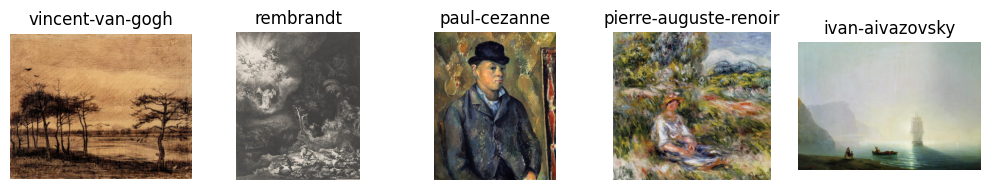

In [6]:
plt.figure(figsize=(10, 2))

for i in range(5):
  artist_id = dataset[i]["artist"]
  plt.subplot(1, 5, i + 1)
  plt.imshow(dataset[i]["image"])
  plt.axis("off")
  plt.title(dataset.features["artist"].int2str(artist_id))

plt.tight_layout()
plt.show()

# Model definition

In [9]:
def create_cnn_model(num_classes):
  """
  Create a simple CNN model for artist classification
  """
  inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

  #x = layers.Resizing(200, 200, crop_to_aspect_ratio=True)(inputs)
  x = layers.Rescaling(1./255)(inputs)

  x = layers.Conv2D(256, (3, 3), activation="relu", padding="same")(x)
  x = layers.MaxPooling2D((2, 2))(x)

  x = layers.Conv2D(512, (3, 3), activation="relu", padding="same")(x)
  x = layers.MaxPooling2D((2, 2))(x)

  x = layers.Conv2D(512, (3, 3), activation="relu", padding="same")(x)
  x = layers.MaxPooling2D((2, 2))(x)

  x = layers.GlobalAveragePooling2D()(x)
  x = layers.Dropout(0.3)(x)

  outputs = layers.Dense(num_classes, activation="softmax")(x)

  return keras.Model(inputs, outputs)

# Train

Epoch 1/30
25/25 - 52s - 2s/step - accuracy: 0.0875 - loss: 3.6164 - val_accuracy: 0.0700 - val_loss: 3.2171
Epoch 2/30
25/25 - 49s - 2s/step - accuracy: 0.1063 - loss: 3.1674 - val_accuracy: 0.1200 - val_loss: 3.0578
Epoch 3/30

Training early stopped on epoch 3 (no improvement in val_loss).
25/25 - 48s - 2s/step - accuracy: 0.1262 - loss: 3.0442 - val_accuracy: 0.1200 - val_loss: 2.9931
4/4 - 5s - 1s/step - accuracy: 0.1500 - loss: 3.2251


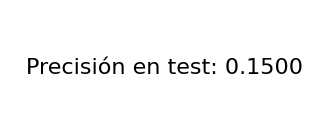

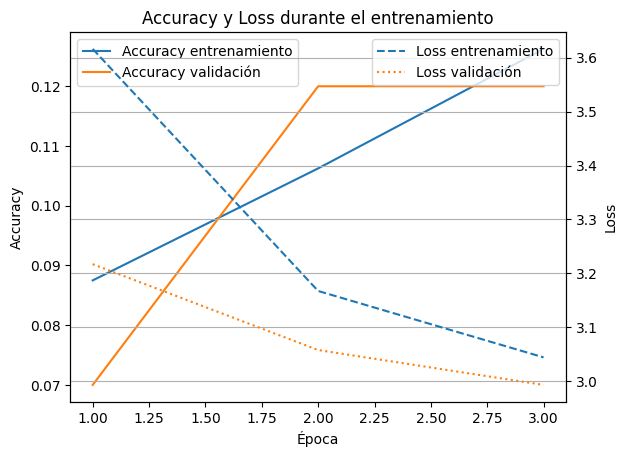

4/4 - 6s - 2s/step


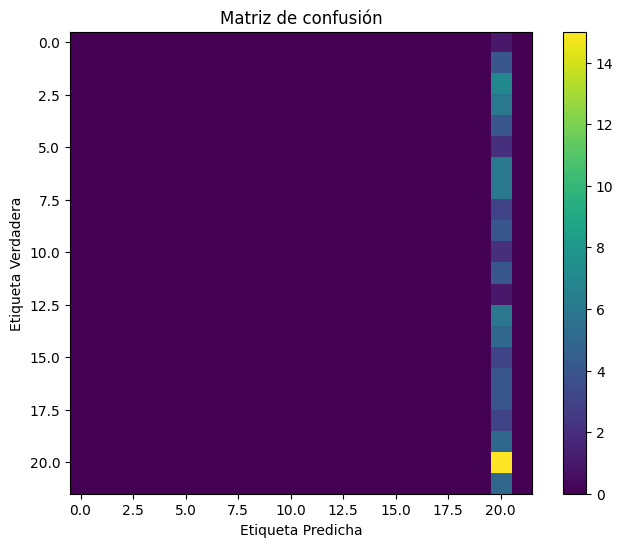

In [20]:
num_classes = dataset.features["artist"].num_classes

model1 = create_cnn_model(num_classes)

history, test_results = train_and_evaluate(
    model = model1,
    train_data = train_ds,
    val_data = val_ds,
    test_data = test_ds,
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"],
    epochs = 30,
    callbacks = [early_stop],
    verbose_level = 2
)

# Reduce learning rate on plateau

In [11]:
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

Epoch 1/30
25/25 - 52s - 2s/step - accuracy: 0.0750 - loss: 3.5935 - val_accuracy: 0.0700 - val_loss: 3.1602 - learning_rate: 0.0010
Epoch 2/30

Epoch 2: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
25/25 - 48s - 2s/step - accuracy: 0.1238 - loss: 3.1550 - val_accuracy: 0.1100 - val_loss: 3.0775 - learning_rate: 0.0010
Epoch 3/30

Training early stopped on epoch 3 (no improvement in val_loss).
25/25 - 48s - 2s/step - accuracy: 0.1275 - loss: 2.9997 - val_accuracy: 0.1000 - val_loss: 3.0095 - learning_rate: 2.0000e-04
4/4 - 4s - 1s/step - accuracy: 0.1500 - loss: 3.1533


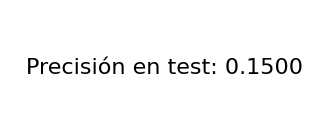

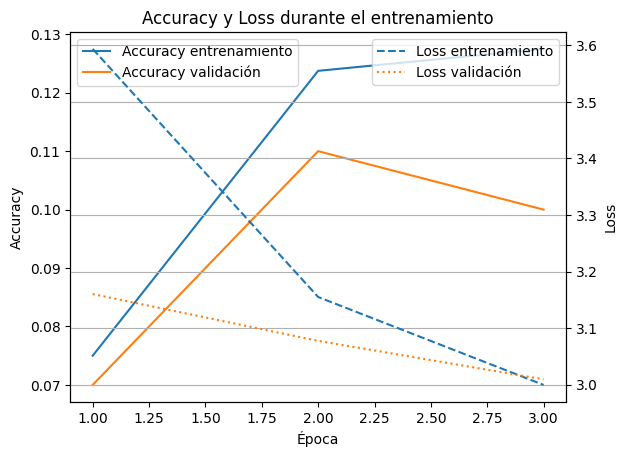

4/4 - 6s - 1s/step


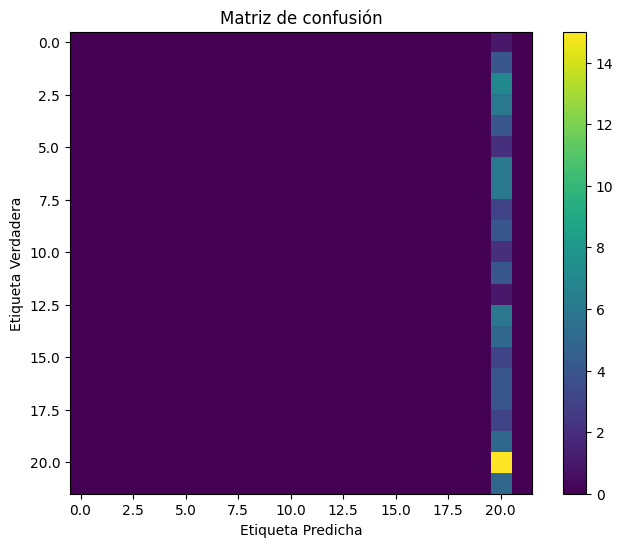

In [21]:
model2 = create_cnn_model(num_classes)

history, test_results = train_and_evaluate(
    model = model2,
    train_data = train_ds,
    val_data = val_ds,
    test_data = test_ds,
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"],
    epochs = 30,
    callbacks = [early_stop, lr_scheduler],
    verbose_level = 2
)

# Transfer learning

In [ ]:
EffNetB0 = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    classes=num_classes,
    classifier_activation="softmax",
    name="efficientnetb0",
)

EffNetB0.trainable = False  # congelar pesos

inputs = keras.layers.Input(shape=(IMG_HEIGHT, IMG_HEIGHT, 3), name='input_layer')

# Redimensionar a 224×224 (EfficientNet espera esta resolución)
x = keras.layers.Resizing(224, 224, name='resize_layer')(inputs)

# Preprocesado específico de EfficientNet
x = keras.applications.efficientnet.preprocess_input(x)
x = EffNetB0(x, training=False)

# Pooling global
x = keras.layers.GlobalAveragePooling2D(name='global_average_pooling_layer')(x)

outputs = keras.layers.Dense(num_classes, activation='softmax', name='output_layer')(x)

model_EffNetB0 = keras.Model(inputs, outputs, name='EfficientNetB0_classif')

BATCH_SIZE = 128

history_EffNetB0, test_results_EffNetB0 = train_and_evaluate(
    model = model_EffNetB0,
    train_data = train_ds,
    val_data = val_ds,
    test_data = test_ds,
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"],
    epochs = 30,
    callbacks = [early_stop],
    verbose_level = 2
)

Epoch 1/30
25/25 - 77s - 3s/step - accuracy: 0.1538 - loss: 3.5777 - val_accuracy: 0.2700 - val_loss: 2.6989
Epoch 2/30
25/25 - 44s - 2s/step - accuracy: 0.4175 - loss: 2.2154 - val_accuracy: 0.4400 - val_loss: 2.2098
Epoch 3/30
